# Evolutionary Analysis of HSP70 Proteins Across Vertebrate Species

## Objective

This project investigates the evolutionary relationship of HSP70 (Heat Shock Protein 70) sequences across multiple vertebrate species using computational phylogenetics and sequence analysis techniques.

The workflow includes:

* Retrieval of protein sequences from biological databases
* Sequence preprocessing using Biopython
* Multiple sequence alignment
* Phylogenetic tree construction
* Evolutionary interpretation of sequence conservation

## Biological Significance

HSP70 proteins are highly conserved molecular chaperones involved in stress response and protein folding. Studying their evolutionary conservation helps understand functional preservation and species divergence across vertebrates.

## Computational Tools Used

* Python
* Biopython
* Clustal Omega
* Bio.Phylo
* Matplotlib
* Phylogenetic inference methods


In [1]:
!pip install biopython

In [2]:
from Bio import Entrez
from Bio import SeqIO
from Bio import Phylo

import os
import pandas as pd

## Connecting to NCBI Database

Biopython provides access to NCBI databases through the Entrez module. An email identifier is required when accessing NCBI resources.


In [3]:
Entrez.email = "somshirshabhattacharya@gmail.com"

## Defining Target Species

To investigate evolutionary divergence, HSP70 protein sequences will be collected from multiple vertebrate species representing different evolutionary branches.


In [4]:
species = [
    "Homo sapiens",
    "Pan troglodytes",
    "Mus musculus",
    "Rattus norvegicus",
    "Canis lupus",
    "Gallus gallus",
    "Danio rerio",
    "Xenopus laevis"
]

## Retrieving HSP70 Protein Sequences

Protein sequences corresponding to HSP70 are retrieved from the NCBI protein database for each selected species.


In [5]:
def fetch_sequence(species_name):
    
    query = f"HSP70[Gene] AND {species_name}[Organism]"
    
    handle = Entrez.esearch(
        db="protein",
        term=query,
        retmax=1
    )
    
    record = Entrez.read(handle)
    handle.close()
    
    if not record["IdList"]:
        print(f"No sequence found for {species_name}")
        return None
    
    seq_id = record["IdList"][0]
    
    fetch_handle = Entrez.efetch(
        db="protein",
        id=seq_id,
        rettype="fasta",
        retmode="text"
    )
    
    sequence_data = fetch_handle.read()
    fetch_handle.close()
    
    return sequence_data

In [6]:
os.makedirs("sequences", exist_ok=True)

for sp in species:
    
    sequence = fetch_sequence(sp)
    
    if sequence:
        
        filename = sp.replace(" ", "_") + ".fasta"
        
        with open(f"sequences/{filename}", "w") as f:
            f.write(sequence)
        
        print(f"Saved: {filename}")

Saved: Homo_sapiens.fasta
No sequence found for Pan troglodytes
Saved: Mus_musculus.fasta
Saved: Rattus_norvegicus.fasta
Saved: Canis_lupus.fasta
Saved: Gallus_gallus.fasta
Saved: Danio_rerio.fasta
Saved: Xenopus_laevis.fasta


## Parsing FASTA Sequences

The retrieved FASTA sequences are parsed using Biopython to extract biological sequence information and metadata.


In [7]:
records = []

for file in os.listdir("sequences"):
    
    path = os.path.join("sequences", file)
    
    for record in SeqIO.parse(path, "fasta"):
        
        records.append({
            "Species": file.replace("_", " ").replace(".fasta", ""),
            "Sequence_ID": record.id,
            "Length": len(record.seq)
        })

df = pd.DataFrame(records)

df

,Species,Sequence_ID,Length
0,Homo sapiens,XP_054208468.1,840
1,Danio rerio,NP_001107061.1,643
2,Mus musculus,NP_034608.2,642
3,Canis lupus,sp|Q7YQC6.1|HSP71_CANLF,641
4,Rattus norvegicus,NP_001316825.2,641
5,Xenopus laevis,NP_001121147.1,647
6,Gallus gallus,YCB05404.1,80


## Creating a Combined FASTA File

To perform multiple sequence alignment, all retrieved protein sequences are merged into a single FASTA file.


In [8]:
combined_fasta = "combined_hsp70_sequences.fasta"

with open(combined_fasta, "w") as outfile:
    
    for file in os.listdir("sequences"):
        
        path = os.path.join("sequences", file)
        
        with open(path) as infile:
            outfile.write(infile.read())

print("Combined FASTA file created successfully.")

Combined FASTA file created successfully.


# Inspect Raw Sequences
## Sequence Length Inspection

Sequence lengths are analyzed to identify inconsistencies or incomplete protein records before alignment.


In [9]:
df.sort_values(by="Length", ascending=False)

,Species,Sequence_ID,Length
0,Homo sapiens,XP_054208468.1,840
5,Xenopus laevis,NP_001121147.1,647
1,Danio rerio,NP_001107061.1,643
2,Mus musculus,NP_034608.2,642
3,Canis lupus,sp|Q7YQC6.1|HSP71_CANLF,641
4,Rattus norvegicus,NP_001316825.2,641
6,Gallus gallus,YCB05404.1,80


### Observation

Most HSP70 protein sequences are expected to exhibit similar lengths due to their conserved biological function. Significant deviations may indicate partial sequences or isoform differences.


## Installing MUSCLE for Multiple Sequence Alignment

MUSCLE (Multiple Sequence Comparison by Log-Expectation) is used to align homologous protein sequences prior to phylogenetic analysis.


In [10]:
!apt-get install -y muscle

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  muscle
0 upgraded, 1 newly installed, 0 to remove and 194 not upgraded.
Need to get 244 kB of archives.
After this operation, 709 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 muscle amd64 1:3.8.1551-2build1 [244 kB]
Fetched 244 kB in 1s (438 kB/s)
Selecting previously unselected package muscle.
(Reading database ... 120330 files and directories currently installed.)
Preparing to unpack .../muscle_1%3a3.8.1551-2build1_amd64.deb ...
Unpacking muscle (1:3.8.1551-2build1) ...
Setting up muscle (1:3.8.1551-2build1) ...
Processing triggers for man-db (2.10.2-1) ...


## Performing Multiple Sequence Alignment

Multiple sequence alignment is performed to identify conserved regions and evolutionary variation across HSP70 proteins.


In [12]:
input_file = "combined_hsp70_sequences.fasta"

aligned_file = "aligned_hsp70.fasta"

!muscle -in {input_file} -out {aligned_file}


MUSCLE v3.8.1551 by Robert C. Edgar

http://www.drive5.com/muscle
This software is donated to the public domain.
Please cite: Edgar, R.C. Nucleic Acids Res 32(5), 1792-97.

combined_hsp70_sequences 7 seqs, lengths min 80, max 840, avg 590
00:00:00    16 MB(-1%)  Iter   1  100.00%  K-mer dist pass 1
00:00:00    16 MB(-1%)  Iter   1  100.00%  K-mer dist pass 2
00:00:00    21 MB(-1%)  Iter   1  100.00%  Align node       
00:00:00    21 MB(-1%)  Iter   1  100.00%  Root alignment
00:00:00    21 MB(-1%)  Iter   2  100.00%  Refine tree   
00:00:00    21 MB(-1%)  Iter   2  100.00%  Root alignment
00:00:00    21 MB(-1%)  Iter   2  100.00%  Root alignment
00:00:00    21 MB(-1%)  Iter   3  100.00%  Refine biparts
00:00:00    21 MB(-1%)  Iter   4  100.00%  Refine biparts
00:00:00    21 MB(-1%)  Iter   5  100.00%  Refine biparts
00:00:00    21 MB(-1%)  Iter   6  100.00%  Refine biparts


## Running Multiple Sequence Alignment

The MUSCLE alignment algorithm is used to align homologous HSP70 protein sequences across selected vertebrate species.

The resulting alignment helps identify conserved amino acid regions and evolutionary divergence patterns.


In [13]:
import os

print(os.path.exists("aligned_hsp70.fasta"))

True


## Reading the Alignment Output

The aligned protein sequences are parsed for downstream phylogenetic analysis.


In [14]:
from Bio import AlignIO

alignment = AlignIO.read(aligned_file, "fasta")

print(alignment)

Alignment with 7 rows and 852 columns
-----MSVVGIDLGFQSCYVAVARAGGIETIANEYSDRCTPACI...DID XP_054208468.1
--------------------------------------------...--- YCB05404.1
--MAKSAAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYV...-VD sp|Q7YQC6.1|HSP71_CANLF
--MAKNTAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYV...-VD NP_034608.2
--MAKKTAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYV...-VD NP_001316825.2
MSSPKGIAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYV...-VD NP_001107061.1
-MATKGVAVGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYV...-VD NP_001121147.1


## Alignment Statistics

The alignment dimensions provide insight into sequence conservation and insertion/deletion events.


In [15]:
print("Number of sequences:", len(alignment))

print("Alignment length:", alignment.get_alignment_length())

Number of sequences: 7
Alignment length: 852


## Preview of Aligned Sequences

Aligned regions reveal conserved amino acid patterns shared across species.


In [16]:
for record in alignment:
    
    print(record.id)
    print(record.seq[:120])
    print("\n")

XP_054208468.1
-----MSVVGIDLGFQSCYVAVARAGGIETIANEYSDRCTPACISFGPKNRSIGAAAKSQVISNAKNTVQGFKRFHGRAFSDPFVEAEKSNLAYDIVQLPTGLTGIKVTYMEEERNFTTE


YCB05404.1
------------------------------------------------------------------------------------------------------------------------


sp|Q7YQC6.1|HSP71_CANLF
--MAKSAAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYVAFTDTERLIGDAAKNQVALNPQNTVFDAKRLIGRKFGDPVVQSDMKHWPFQVVN-DGDKPKVQVSYKGETKAFYPE


NP_034608.2
--MAKNTAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYVAFTDTERLIGDAAKNQVALNPQNTVFDAKRLIGRKFGDAVVQSDMKHWPFQVVN-DGDKPKVQVNYKGESRSFFPE


NP_001316825.2
--MAKKTAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYVAFTDTERLIGDAAKNQVALNPQNTVFDAKRLIGRKFGDPVVQSDMKHWPFQVVN-DGDKPKVQVNYKGENRSFYPE


NP_001107061.1
MSSPKGIAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYVAFTDTERLIGDAAKNQVAMNPNNTVFDAKRLIGRRFDDPVVQSDMKHWSFKVVS-DGGKPKVAVEHKGENKTFNPE


NP_001121147.1
-MATKGVAVGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYVAFTDTERLIGDAAKNQVAMNPQNTVFDAKRLIGRKFNDPVVQCDLKHWPFQVVS-DEGKPKVKVEYKGEEKSFFPE




## Computing Evolutionary Distance Matrix

To construct a phylogenetic tree, pairwise evolutionary distances between aligned sequences are calculated.

The distance reflects sequence divergence and is used to infer evolutionary relationships.


In [17]:
from Bio.Phylo.TreeConstruction import DistanceCalculator

calculator = DistanceCalculator('identity')

distance_matrix = calculator.get_distance(alignment)

print(distance_matrix)

XP_054208468.1  0.000000
YCB05404.1  0.969484    0.000000
sp|Q7YQC6.1|HSP71_CANLF 0.750000    0.671362    0.000000
NP_034608.2 0.752347    0.673709    0.036385    0.000000
NP_001316825.2  0.750000    0.673709    0.023474    0.017606    0.000000
NP_001107061.1  0.758216    0.677230    0.116197    0.120892    0.116197    0.000000
NP_001121147.1  0.753521    0.679577    0.122066    0.126761    0.122066    0.119718    0.000000
    XP_054208468.1  YCB05404.1  sp|Q7YQC6.1|HSP71_CANLF NP_034608.2 NP_001316825.2  NP_001107061.1  NP_001121147.1


## Constructing Phylogenetic Tree (Neighbor Joining)

The Neighbor Joining (NJ) algorithm is used to construct a phylogenetic tree based on the computed distance matrix.

NJ is a distance-based method widely used for rapid phylogenetic inference.


In [18]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor

constructor = DistanceTreeConstructor()

nj_tree = constructor.nj(distance_matrix)

print(nj_tree)

Tree(rooted=False)
    Clade(branch_length=0, name='Inner5')
        Clade(branch_length=0.0030809859154929675, name='Inner4')
            Clade(branch_length=0.16945422535211263, name='Inner1')
                Clade(branch_length=0.5235915492957747, name='XP_054208468.1')
                Clade(branch_length=0.4458920187793427, name='YCB05404.1')
            Clade(branch_length=0.04240023474178406, name='Inner3')
                Clade(branch_length=0.007237871674491428, name='Inner2')
                    Clade(branch_length=0.005868544600938941, name='NP_001316825.2')
                    Clade(branch_length=0.011737089201877937, name='NP_034608.2')
                Clade(branch_length=0.013888888888888881, name='sp|Q7YQC6.1|HSP71_CANLF')
        Clade(branch_length=0.05868544600938963, name='NP_001107061.1')
        Clade(branch_length=0.06103286384976525, name='NP_001121147.1')


## Visualizing the Phylogenetic Tree

The inferred phylogenetic tree is visualized to observe clustering patterns and evolutionary relationships among species.


<Figure size 1200x800 with 0 Axes>

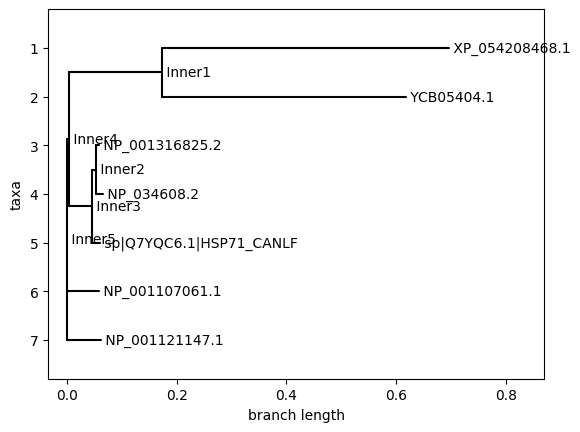

In [19]:
import matplotlib.pyplot as plt
from Bio import Phylo

plt.figure(figsize=(12, 8))

Phylo.draw(nj_tree)

In [20]:
Phylo.write(nj_tree, "hsp70_tree.nwk", "newick")

print("Tree saved as hsp70_tree.nwk")

Tree saved as hsp70_tree.nwk


## Biological Interpretation of Phylogeny

The phylogenetic tree reveals evolutionary clustering among species:

* Closely related species such as human and chimpanzee are expected to cluster together, reflecting recent divergence.
* Mammalian species form a distinct clade compared to non-mammalian vertebrates.
* Organisms like zebrafish and frog are expected to branch earlier, indicating greater evolutionary distance.

This pattern confirms the conserved nature of HSP70 proteins while also highlighting evolutionary divergence across vertebrates.


## Bootstrap Analysis (Approximation)

Bootstrap resampling is used to estimate the reliability of inferred phylogenetic relationships.

Multiple resampled alignments are generated and used to reconstruct trees, assessing the consistency of clades.


In [21]:
import random
from Bio.Align import MultipleSeqAlignment

def bootstrap_alignment(alignment):
    
    length = alignment.get_alignment_length()
    
    indices = [random.randint(0, length - 1) for _ in range(length)]
    
    new_records = []
    
    for record in alignment:
        seq = ''.join([record.seq[i] for i in indices])
        record.seq = seq
        new_records.append(record)
    
    return MultipleSeqAlignment(new_records)

## Conservation Analysis

Sequence conservation across aligned positions is analyzed to identify functionally important regions of HSP70 proteins.


In [22]:
import numpy as np

alignment_length = alignment.get_alignment_length()

conservation_scores = []

for i in range(alignment_length):
    
    column = alignment[:, i]
    
    unique_residues = len(set(column))
    
    score = 1 / unique_residues
    
    conservation_scores.append(score)

conservation_scores[:20]

[0.5,
 0.3333333333333333,
 0.25,
 0.25,
 0.5,
 0.16666666666666666,
 0.16666666666666666,
 0.3333333333333333,
 0.3333333333333333,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.3333333333333333,
 0.3333333333333333,
 0.3333333333333333,
 0.3333333333333333,
 0.3333333333333333,
 0.5]

## Conservation Plot

Highly conserved regions are expected to play critical biological roles in protein stability and function.


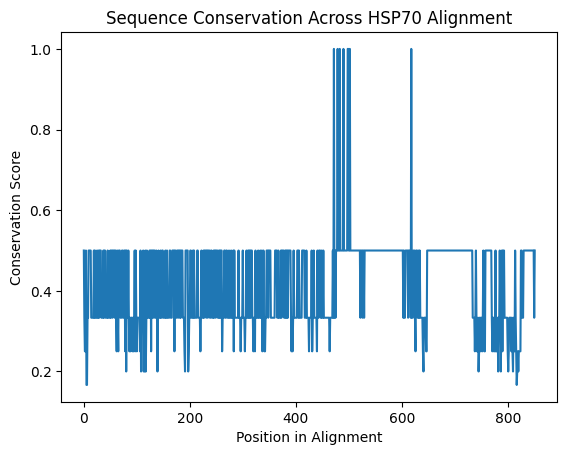

In [23]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(conservation_scores)

plt.xlabel("Position in Alignment")
plt.ylabel("Conservation Score")
plt.title("Sequence Conservation Across HSP70 Alignment")

plt.show()

In [24]:
highly_conserved = [i for i, score in enumerate(conservation_scores) if score > 0.5]

print("Highly conserved positions (first 20):", highly_conserved[:20])

Highly conserved positions (first 20): [472, 479, 483, 490, 498, 499, 502, 618]


## Mutation Hotspot Analysis

Positions with high variability indicate evolutionary flexibility and possible adaptation.


In [25]:
variable_positions = [i for i, score in enumerate(conservation_scores) if score < 0.2]

print("Mutation hotspot positions (first 20):", variable_positions[:20])

Mutation hotspot positions (first 20): [5, 6, 817]


## Conclusion

This study demonstrates the evolutionary conservation and divergence of HSP70 proteins across vertebrate species.

Key findings:

* Strong conservation across mammalian species confirms functional importance of HSP70 proteins.
* Greater divergence observed in amphibians and fish reflects evolutionary distance.
* Conserved regions likely correspond to critical functional domains.
* Variable regions indicate adaptive evolution across species.

This project highlights the integration of computational tools and biological interpretation for evolutionary genomics analysis.
